# UNO Vision Challenge

This notebook illustrates the vision pipeline implemented to solve the UNO Vision Challenge (expliquer).  The pipeline relies both on classical vision methods, for segmentation, and deep learning methods, for classification.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

PROJECT_DIR = Path.cwd() / "project" if (Path.cwd() / "project").exists() else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from segmentation import segmentation_utils as seg
from cnn import DEFAULT_MODEL_PATH, Classifier
from notebook_utils import *

BASE_DIR = Path(seg.BASE_DIR)
TEST_DIR = seg.TEST_DIR
TEST_IMAGES_DIR = TEST_DIR
MODEL_PATH = DEFAULT_MODEL_PATH
HISTORY_PATH = PROJECT_DIR / "symbol_cnn_history.json"

DEMO_IMAGE_PATHS = [
    TEST_DIR / "L1001001.jpg",  # shared segmentation/CNN demo image
    TEST_DIR / "L1000896.jpg",  # white background, grey token
]

demo_images = [Image.open(path).convert("RGB") for path in DEMO_IMAGE_PATHS]
IMAGE_PATH = DEMO_IMAGE_PATHS[0]
img_color = demo_images[0]



# Segmentation

## Input Images

The dataset contains two visual setups. Some images are taken on a colorful table background with a yellow circular active-player token, while others are taken on a white background with a grey rectangular token. The token is important for the final pipeline because it identifies the active player, but it also interferes with color segmentation if it is not handled explicitly.

We display one example of each setup here to verify that the pipeline recognizes both cases. The rest of the notebook then continues with `IMAGE_PATH`, the same frame used later for the CNN patch demo, so the segmentation and classification examples follow one continuous image.



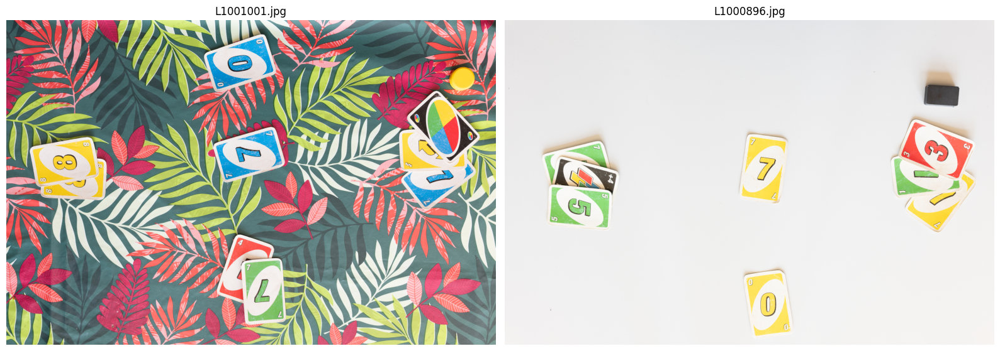

In [2]:
fig, axes = plt.subplots(1, len(demo_images), figsize=(8 * len(demo_images), 6))
axes = np.atleast_1d(axes)

for ax, path, image in zip(axes, DEMO_IMAGE_PATHS, demo_images):
    show_image(image, path.name, ax=ax)

plt.tight_layout()


## Image Type And Token Center

The first decision is which type of active-player token is present. `image_token_type` uses the average image brightness as a simple cue: white-background images are much brighter overall and use the grey token, while colorful-background images are darker overall and use the yellow token.

`get_token_center` then uses a different localization method for each token type. For the yellow token, the pipeline thresholds yellow pixels and looks for a circular component with `find_circle_hough`, because the token is approximately round. For the grey token, the pipeline thresholds the grey HSV range, keeps the largest connected component with `biggest_object`, and returns its centroid with `mask_center`.



L1001001.jpg: detected token type = yellow; token center = (3733, 485)
L1000896.jpg: detected token type = grey; token center = (3570, 622)


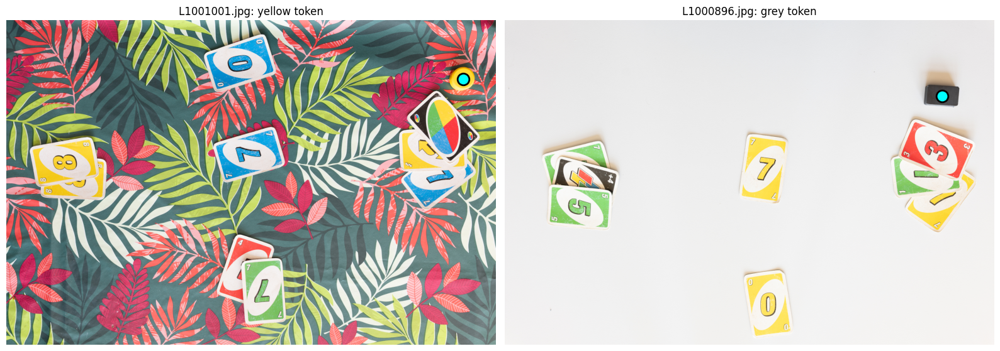

In [3]:
fig, axes = plt.subplots(1, len(demo_images), figsize=(8 * len(demo_images), 6))
axes = np.atleast_1d(axes)

for ax, path, image in zip(axes, DEMO_IMAGE_PATHS, demo_images):
    token = seg.image_token_type(image)
    token_center = seg.get_token_center(image)
    print(f"{path.name}: detected token type = {token}; token center = {token_center}")

    show_image(image, f"{path.name}: {token} token", ax=ax)
    if token_center is not None:
        ax.scatter(*token_center, s=180, c="cyan", edgecolors="black", linewidths=2)

plt.tight_layout()


For the rest of the pipeline demonstration we focus on `IMAGE_PATH`. The CNN section reuses this same frame, which keeps the intermediate masks, extracted patches, and classified symbols tied to one scene.



## Color Masks

The pipeline starts by separating the image into one binary mask per UNO color: blue, green, red, yellow, black, and white. We decided to do this to exploit the color design of the cards. `get_color_masks` loads the HSV ranges from `hsv_thresholds/`, applies `cv2.inRange` for each configured range, and combines the ranges belonging to the same color. Each of the hsv thresholds defined by the .txt files in the `hsv_thresholds/` were chosen manually on a sample of training images using the `hsv_tuner.py` tool.

HSV is used instead of raw RGB because hue and saturation are more stable under changes in brightness, and allow for easier segmentation of the different colors. After thresholding, each mask is morphologically closed with `morph_close` to fill small gaps, then passed through `min_area_filter` so small components are removed.



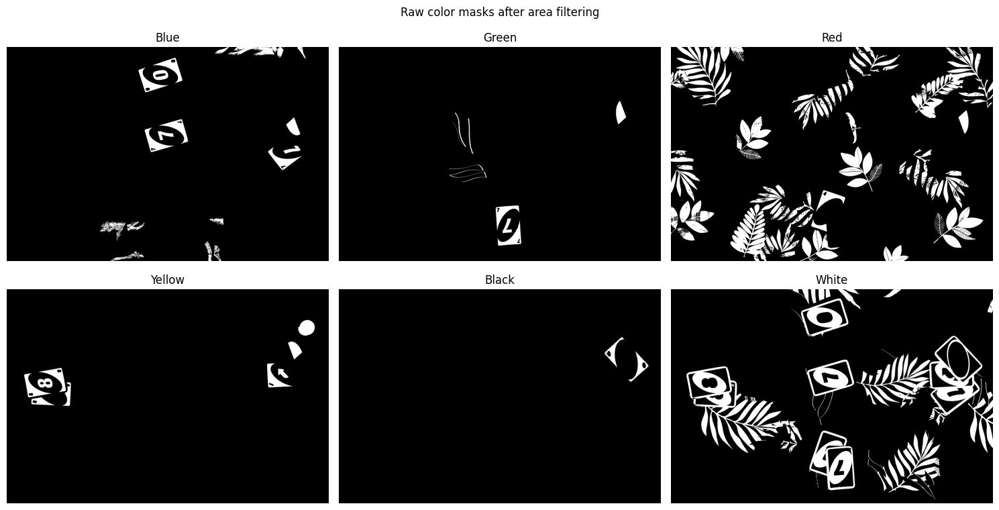

In [4]:
color_masks = seg.get_color_masks(img_color)
show_masks(color_masks, title="Raw color masks after area filtering")


At this point in the pipeline, we can see some card parts as well as a lot of noisy elements, especially from the background. The next steps will focus on refining this segmentation of cards.

## Token Removal

The active-player token can have the same color as objects we care about. On colorful backgrounds the token is yellow, so it may be mistaken for a yellow card region. On white-background images the grey token can overlap with the black mask.

`remove_token_from_color_masks` solves this problem by forcing to 0 pixels from the yellow/black masks, if their coordinates correspond to coordinates of token pixels. 


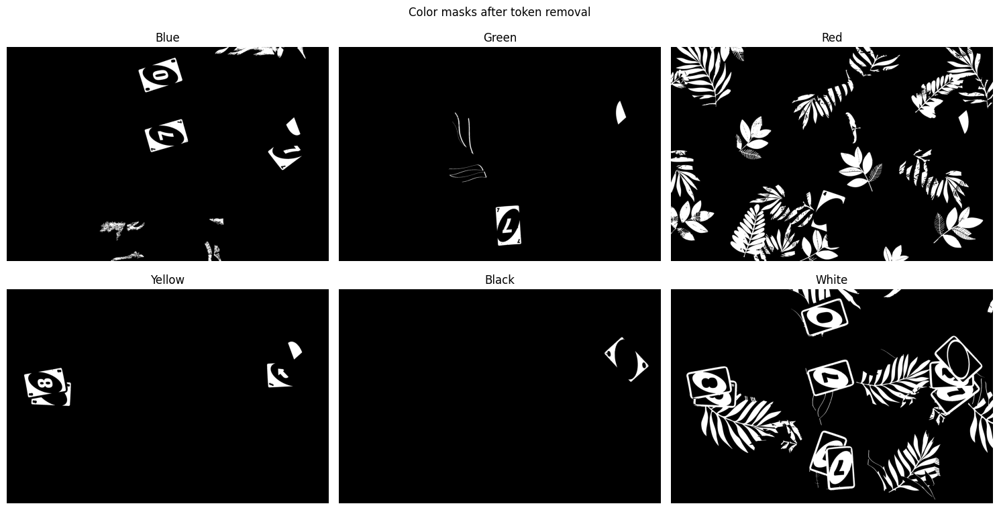

In [5]:
token_removed_masks = seg.remove_token_from_color_masks(
    img_color,
    {color: mask.copy() for color, mask in color_masks.items()},
)
show_masks(token_removed_masks, title="Color masks after token removal")


We can see that the yellow token that previously appeared in the yellow mask has been suppressed and can no longer be mistaken for a card in the rest of the pipeline.

## Keep Card-Like Objects

After color thresholding, a mask may still contain non-card objects: table artifacts, shadows, parts of the token that survived the previous step, or noise that survived the area filter. The UNO cards in these images have a useful structural property: colored card interiors are surrounded by a white border.

`keep_white_surrounded_objects` uses that property to keep only colored components that look card-like. For each connected component, `keep_objects_surrounded_by_white` builds a ring around the object by dilating it and subtracting the original object. It then measures how much of that ring overlaps the white mask. Components with enough surrounding white are retained; the others are discarded.


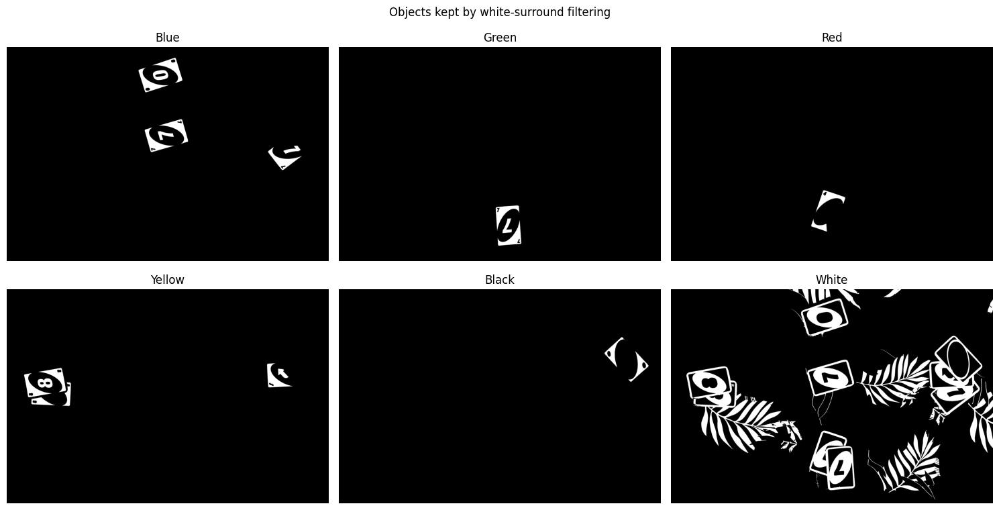

In [6]:
card_masks = seg.keep_white_surrounded_objects(
    {color: mask.copy() for color, mask in token_removed_masks.items()}
)
show_masks(card_masks, title="Objects kept by white-surround filtering")


As we can see, this additional condition for card objects allowed us to remove all the non-card objects from the blue, green, red, yellow, and black masks, which is exactly what we needed for the following steps in the pipeline.

## Holes Inside Card Shapes

Once card-like colored regions are isolated, the next idea is to look for holes inside them. In a binary card mask, white printed symbols appear as missing pixels inside the colored region. `get_holes` fills the exterior background, finds enclosed empty regions, and returns those enclosed regions as candidate symbol pixels.

This step is useful because it turns the symbol search into a shape problem: instead of detecting every possible card symbol directly in RGB space, we first ask which white regions are enclosed by colored cards. The visualization below shows all such enclosed regions before the stricter filtering is applied.



<Axes: title={'center': 'All holes inside colored card regions'}>

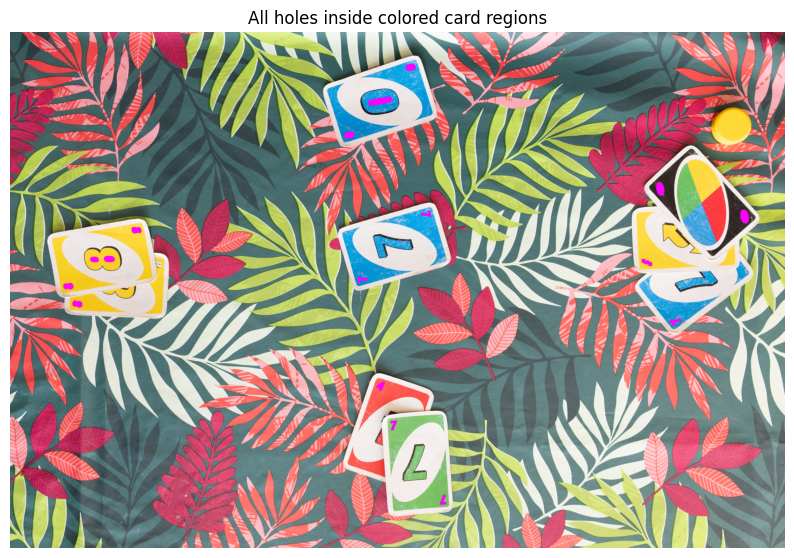

In [7]:
hole_masks = {
    color: seg.get_holes(mask, min_hole_area=100)
    for color, mask in card_masks.items()
    if color != "white"
}
all_holes = np.bitwise_or.reduce(list(hole_masks.values()))
overlay_mask(img_color, all_holes, title="All holes inside colored card regions")


This raw hole-based method is intentionally over-inclusive. Some center symbols contain internal holes themselves, such as `0`, `4`, `6`, `8`, `9`, skip, and `+4`. Those inner holes are not corner symbols, but they are still enclosed by colored pixels, so they appear as candidates.

The next stage filters these candidates using card layout. Corner symbols sit near the white card border, while holes inside the large center symbol remain farther from that border. That spatial difference is what lets us reject many false candidates without needing a classifier yet.



## Filtered Symbol Masks

`extract_symbols_mask_per_color` applies the full symbol-candidate filtering strategy. It starts from the holes found inside each colored card mask, then keeps candidates that are plausible corner symbols.

The key helper is `filter_shapes_by_dilated_ring_overlap_binary`. For each candidate shape, the function dilates the shape and inspects only the newly added ring around it. If that ring overlaps enough white border pixels, the candidate is kept. This works because corner symbols are close enough to the card border for their dilation ring to touch white, while false holes inside the central symbol usually stay trapped inside the colored/central-symbol area.

The function also intersects candidates with `white_by_hsv`, a low-saturation mask, to prefer white or near-white symbol pixels and reject colorful artifacts. The result is one cleaned symbol mask per card color.



<Axes: title={'center': 'Final symbol pixels overlaid on the input'}>

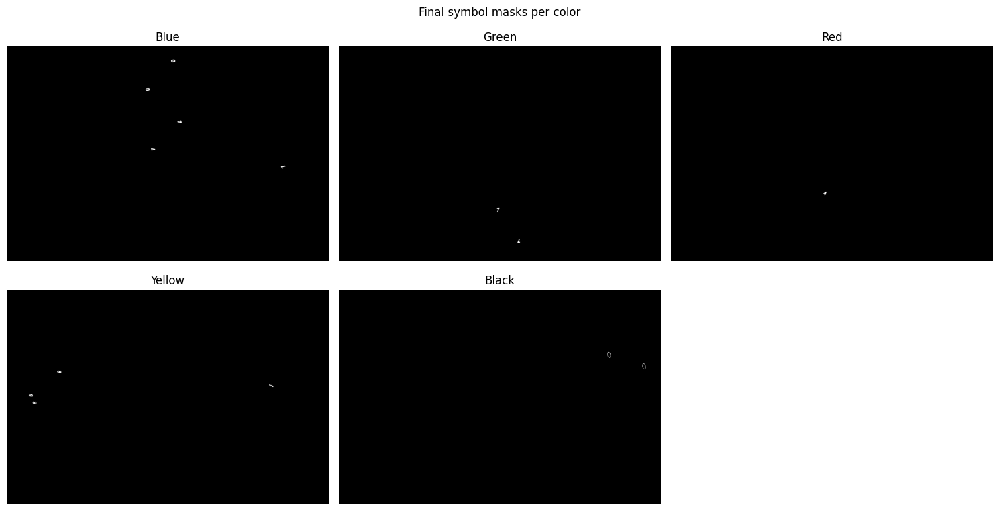

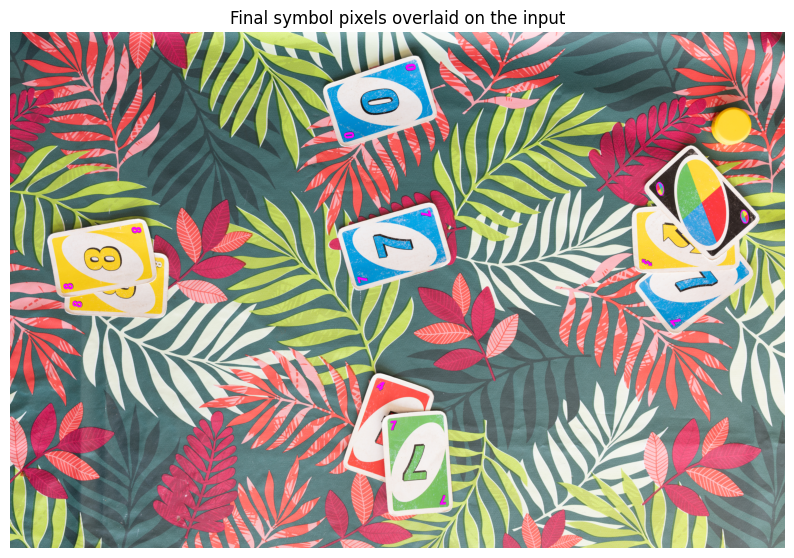

In [8]:
symbols_mask_per_color = seg.extract_symbols_mask_per_color(img_color, card_masks)
total_symbol_mask = np.bitwise_or.reduce(list(symbols_mask_per_color.values()))

show_masks(symbols_mask_per_color, columns=3, title="Final symbol masks per color")
overlay_mask(img_color, total_symbol_mask, title="Final symbol pixels overlaid on the input")


As we can see in the result image, the corner symbols are now perfectly detected while other previous candidates like the holes in the big center 6 and 8 have been ignored.

## Extracted Symbol Patches

The final segmentation output must be usable by the CNN classifier. `detect_symbols` therefore wraps all previous steps and converts the final symbol masks into individual records.

Inside it, `extract_merged_symbol_records` merges nearby foreground pixels that belong to the same printed symbol, computes each symbol center in the original image, and calls `crop_centered_binary_mask` to create a fixed-size binary patch around the symbol. Each returned record contains the patch, the card color, and the image-space center. The classifier later predicts the symbol label from the patch, while the color and center are used to reconstruct the card and assign it to a player or the table.



Detected symbols: 14


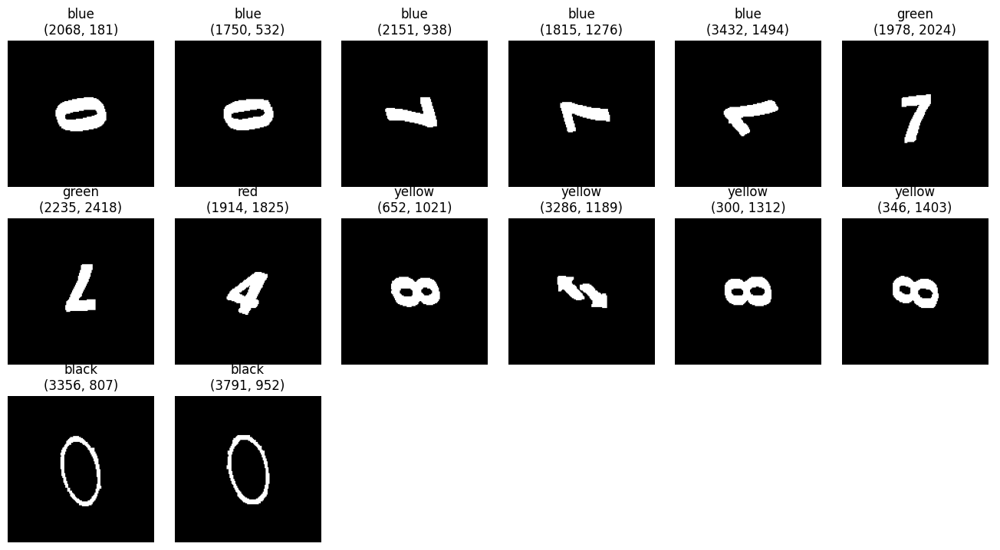

In [9]:
detected_symbols = seg.detect_symbols(img_color)
print(f"Detected symbols: {len(detected_symbols)}")

columns = min(6, max(1, len(detected_symbols)))
rows = int(np.ceil(len(detected_symbols) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(2.2 * columns, 2.4 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, (patch, color, center_xy) in zip(axes, detected_symbols):
    ax.imshow(patch, cmap="gray")
    ax.set_title(f"{color}\n({center_xy[0]:.0f}, {center_xy[1]:.0f})")
    ax.axis("off")

for ax in axes[len(detected_symbols):]:
    ax.axis("off")

plt.tight_layout()


# Data Preparation for CNN Classification

## Symbols Dataset Creation

blablabla

## Symbols Dataset Labeling

blablabla

## Context

This notebook prepares the training and validation datasets used to train a **Convolutional Neural Network (CNN)** for symbol recognition.

CNNs are data-hungry: a rule of thumb for image classification is to have at least **500–1 000 labelled examples per class**, with more being better for generalisation. We have **15 symbol classes**, so we target:

| Split | Per-class target | Total |
|---|---|---|
| **Train** | ~667 | **10 000** |
| **Validation** | ~222 | **3 333** |

### Why 10 000 training images?

10 000 images (≈ 667 per class) sits in the sweet spot for a CNN of this complexity:
- Below ~500/class, CNNs overfit quickly — the model memorises the training set rather than learning the underlying shape.
- Above ~1 000/class, gains diminish rapidly for simple binary symbols, and augmentation artefacts start to dominate.
- 10 000 also gives a round budget that is easy to reason about and reproduce.

### Why a 75 / 25 train-validation split?

A naive 90/10 split would yield only ~50 validation images per class, making the validation accuracy **highly volatile**: a single misclassified batch could swing the metric by several percent, which makes hyper-parameter tuning unreliable. A **25 % validation set (~222 images/class)** gives a stable, low-variance estimate of generalisation performance while still leaving 75 % of the data for training — sufficient given that we are augmenting from a much smaller original set.

### What augmentation does

The original dataset has very few images per class. Augmentation synthetically expands it by applying **random rotation (0–360°)** and **small random translations (±10 px)** to existing images, then **re-binarizing** to preserve the hard black/white look of the originals (bilinear interpolation otherwise produces grey anti-aliasing artefacts). Only the *missing* images needed to reach the target are generated — originals are never duplicated or altered.

---

**Files used by this notebook**
| File | Role |
|---|---|
| `augmentation_utils.py` | All pipeline functions (I/O, splitting, augmentation, …) |
| `notebook_utils.py` | Visualisation helpers (bar plots, count summaries) |

## 0 — Imports

In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image

from augmentation_utils import (
    load_json,
    save_json,
    count_files,
    compute_targets,
    group_by_class,
    stratified_split,
    copy_images,
    next_available_index,
    complete_split,
    prepare_output_dir,
    augment_image,
)

from notebook_utils import (
    plot_distribution,
    plot_distributions_grid,
    print_split_counts,
)

## 1 — Configuration

The two knobs below drive every downstream computation. Change them here; targets are derived automatically — no hardcoded numbers elsewhere.

| Parameter | Value | Meaning |
|---|---|---|
| `TOTAL_TRAIN` | 10 000 | Total training images across all classes |
| `VAL_RATIO` | 0.25 | Fraction of the full dataset kept for validation |

In [11]:
DATA_DIR   = "symbols_dataset"       # original images + labels.json
OUT_DIR    = "augm_symbols_dataset"  # output folder (created if missing)

TOTAL_TRAIN = 10_000   # desired total training images
VAL_RATIO   = 0.25     # 25 % of the full dataset → validation

## 2 — Load original labels & compute targets

`compute_targets` uses the formula:

```
train_per_class = TOTAL_TRAIN // num_classes
val_per_class   = train_per_class × VAL_RATIO / (1 − VAL_RATIO)
```

This ensures the ratio is exact regardless of `TOTAL_TRAIN` or the number of classes.

In [12]:
labels      = load_json(os.path.join(DATA_DIR, "labels.json"))
num_classes = len(set(labels.values()))

TRAIN_TARGET, VAL_TARGET = compute_targets(
    num_classes=num_classes,
    total_train=TOTAL_TRAIN,
    val_ratio=VAL_RATIO,
)

print(f"Classes detected : {num_classes}")
print(f"Original images  : {len(labels)}")
print()
print(f"Train target  : {TRAIN_TARGET:>5} / class  →  {TRAIN_TARGET * num_classes:>6} total")
print(f"Val   target  : {VAL_TARGET:>5} / class  →  {VAL_TARGET   * num_classes:>6} total")
print(f"Effective val ratio : {VAL_TARGET / (TRAIN_TARGET + VAL_TARGET):.1%}")

Classes detected : 15
Original images  : 1090

Train target  :   666 / class  →    9990 total
Val   target  :   222 / class  →    3330 total
Effective val ratio : 25.0%


## 3 — Original dataset distribution

Bar chart of the raw symbol counts before any splitting or augmentation.

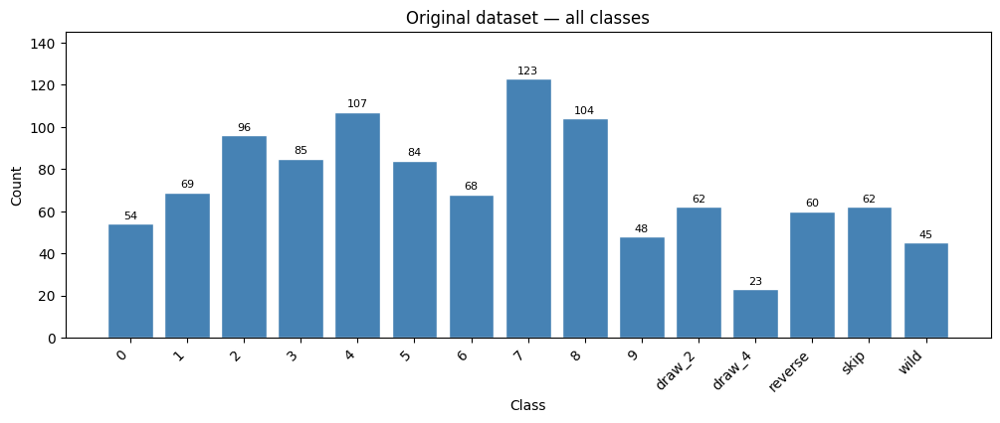

In [13]:
plot_distribution("Original dataset — all classes", labels)
plt.show()

## 4 — Stratified 75 / 25 train / validation split

`stratified_split` shuffles each class independently (with a fixed seed for reproducibility), then assigns the first `VAL_RATIO` fraction to validation and the rest to training. This ensures the class distribution is identical in both splits.

In [14]:
train_labels, val_labels = stratified_split(labels, val_ratio=VAL_RATIO, seed=42)

print(f"Original total : {len(labels)}")
print(f"→ Train        : {len(train_labels)}")
print(f"→ Validation   : {len(val_labels)}")

print_split_counts(
    train_labels, val_labels,
    TRAIN_TARGET, VAL_TARGET,
    num_classes,
    stage="Before augmentation (originals only)",
)

Original total : 1090
→ Train        : 822
→ Validation   : 268

──────────────────────────────────────────────  Before augmentation (originals only)
  Split          Images  Expected   OK
  ──────────── ────────  ────────  ───
  Train             822      9990    ✗
  Validation        268      3330    ✗
  TOTAL            1090     13320
──────────────────────────────────────────────


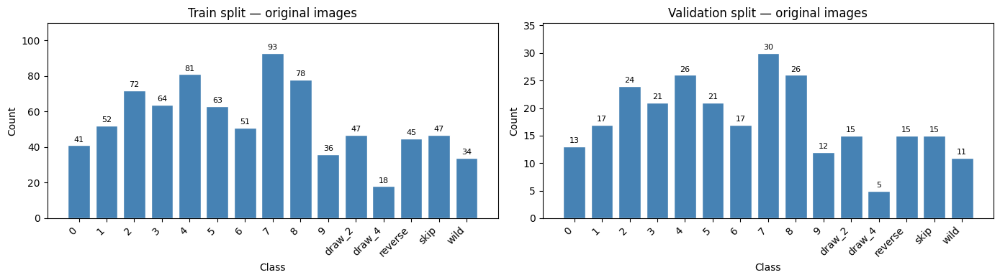

In [15]:
plot_distributions_grid([
    ("Train split — original images", train_labels),
    ("Validation split — original images", val_labels),
])

## 5 — Prepare output folder & copy originals

`prepare_output_dir` checks whether the output folder already contains images **and** both JSON split files:
- If yes → returns `False` and loads from disk (no duplication, no re-augmentation).
- If no → creates the folder and returns `True`.
- If partially populated → raises an error (interrupted previous run, needs manual cleanup).

Original images are copied first; only the *missing* images are then generated by augmentation.

In [16]:
is_fresh_run = prepare_output_dir(OUT_DIR)

if is_fresh_run:
    # Save initial (pre-augmentation) split JSONs
    save_json(train_labels, os.path.join(OUT_DIR, "train.json"))
    save_json(val_labels,   os.path.join(OUT_DIR, "val.json"))

    # Copy original images to output folder
    all_images = list(train_labels.keys()) + list(val_labels.keys())
    copy_images(all_images, src_dir=DATA_DIR, dst_dir=OUT_DIR)

    orig_count, _ = count_files(DATA_DIR)
    out_count,  _ = count_files(OUT_DIR)
    print(f"Original dataset : {orig_count} images")
    print(f"Copied to output : {out_count} images")
else:
    # Folder already complete — reload splits from disk
    train_labels = load_json(os.path.join(OUT_DIR, "train.json"))
    val_labels   = load_json(os.path.join(OUT_DIR, "val.json"))
    print(f"Loaded existing splits — train: {len(train_labels)}, val: {len(val_labels)}")

[INFO] 'augm_symbols_dataset' already contains 13320 images and both split JSONs — skipping generation.
Loaded existing splits — train: 9990, val: 3330


## 6 — Augmentation examples

One original image alongside 5 augmented variants: random rotation (full 360°) + small translation (±10 px) + re-binarization.

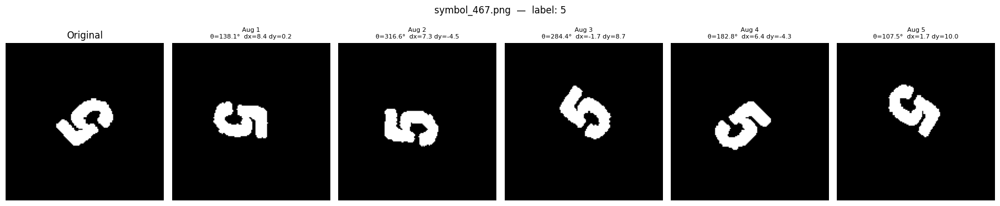

In [17]:
sample_name = list(train_labels.keys())[0]
sample_img  = Image.open(os.path.join(DATA_DIR, sample_name)).convert("RGB")

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(5):
    aug, angle, tx, ty = augment_image(sample_img)
    axes[i + 1].imshow(aug, cmap="gray")
    axes[i + 1].set_title(f"Aug {i+1}\nθ={angle:.1f}°  dx={tx:.1f} dy={ty:.1f}", fontsize=8)
    axes[i + 1].axis("off")

plt.suptitle(f"{sample_name}  —  label: {train_labels[sample_name]}")
plt.tight_layout()
plt.show()

## 7 — Balance both splits by augmentation

For each class, `complete_split` counts how many images are **already present** in the split and only generates the **missing** ones needed to reach the target. Images that already exist are never duplicated or re-processed.

One progress bar is shown per split (not one per class), so the output stays readable.

In [18]:
if is_fresh_run:
    start_idx = next_available_index([train_labels, val_labels])

    new_train, start_idx = complete_split(
        split_labels=train_labels,
        target_count=TRAIN_TARGET,
        src_dir=DATA_DIR,
        out_dir=OUT_DIR,
        start_index=start_idx,
        split_name="TRAIN",
    )

    new_val, _ = complete_split(
        split_labels=val_labels,
        target_count=VAL_TARGET,
        src_dir=DATA_DIR,
        out_dir=OUT_DIR,
        start_index=start_idx,
        split_name="VALIDATION",
    )

    # Overwrite JSONs with the final (augmented) label mappings
    save_json(new_train, os.path.join(OUT_DIR, "train.json"))
    save_json(new_val,   os.path.join(OUT_DIR, "val.json"))
    print("Saved final train.json and val.json")
else:
    new_train = train_labels
    new_val   = val_labels
    print("Augmentation skipped — output folder already complete.")

Augmentation skipped — output folder already complete.


## 8 — Final counts & distribution

Verify that both splits reached their targets (✓) and inspect the per-class bar charts.

In [19]:
print_split_counts(
    new_train, new_val,
    TRAIN_TARGET, VAL_TARGET,
    num_classes,
    stage="After augmentation",
)

total_out, _ = count_files(OUT_DIR)
print(f"\nTotal image files in '{OUT_DIR}': {total_out}")


──────────────────────────────────────────────  After augmentation
  Split          Images  Expected   OK
  ──────────── ────────  ────────  ───
  Train            9990      9990    ✓
  Validation       3330      3330    ✓
  TOTAL           13320     13320
──────────────────────────────────────────────

Total image files in 'augm_symbols_dataset': 13320


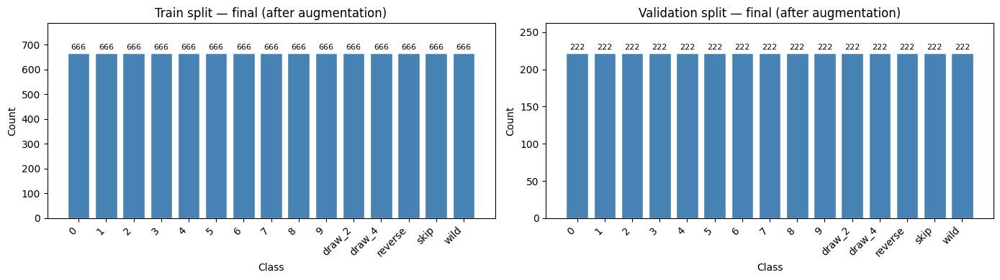

In [20]:
plot_distributions_grid([
    ("Train split — final (after augmentation)", new_train),
    ("Validation split — final (after augmentation)", new_val),
])

# CNN Classification

This notebook summarizes the final pipeline as a short report. It covers:
- CNN training/loading,
- CNN performance on the symbol dataset,
- one-frame examples of symbol prediction,
- token attribution, center-card attribution, player-card attribution,
- the logic used to delete duplicated card detections,
- one full pipeline run on a frame.


## 1. Shared Setup

The imports and shared paths were defined at the start of the notebook. We reuse those objects here so the CNN results continue from the segmentation demo instead of restarting with a separate setup.


In [21]:
print('Project dir:', PROJECT_DIR)
print('Model path:', MODEL_PATH)
print('History path:', HISTORY_PATH)
print('Shared demo frame:', IMAGE_PATH.name)


Project dir: C:\Users\ayoub\Code\IAPR_gr69\project
Model path: C:\Users\ayoub\Code\IAPR_gr69\project\symbol_cnn.pt
History path: C:\Users\ayoub\Code\IAPR_gr69\project\symbol_cnn_history.json
Shared demo frame: L1001001.jpg


## 2. Train the CNN if needed


In [22]:
model_path, history_path, history, trained_now = ensure_model(
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    device='auto',
)

print('Model created in this notebook run:', trained_now)
print('Model exists:', model_path.exists())
print('History available:', history is not None)


Model created in this notebook run: False
Model exists: True
History available: True


## 3. CNN performance on the symbol dataset

We evaluate the saved model on the validation split (`validation.json`) and display standard classification metrics.


In [23]:
metrics, confusion_matrix, idx_to_class = evaluate_model(model_path=MODEL_PATH, device='auto')
metrics


{'accuracy': 1.0, 'macro_f1': 1.0, 'weighted_f1': 1.0}

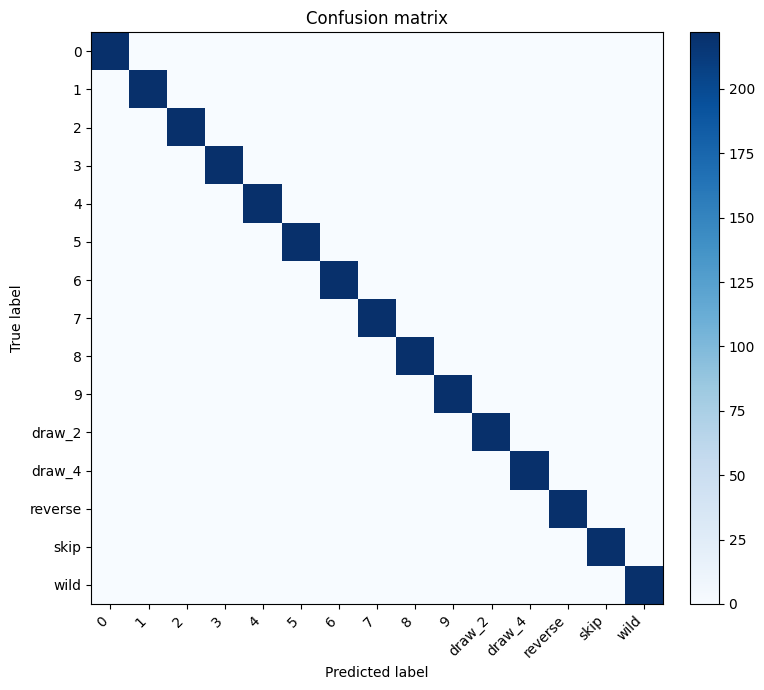

In [24]:
plot_confusion_matrix(confusion_matrix, idx_to_class)
plt.show()


### Training curves

If training history is available, we display the evolution of training and validation accuracy/loss over epochs.


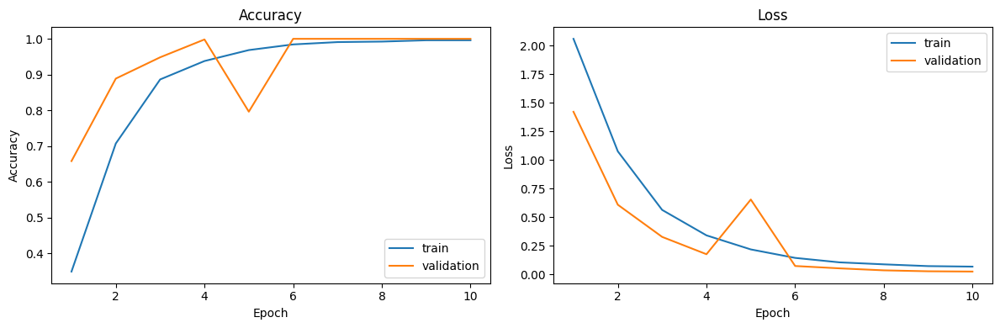

In [25]:
plot_history(history)
plt.show()


## 4. Run the CNN on one frame

The segmentation module first extracts symbol patches from the shared demo image, then the CNN classifies each patch. The figures below show example patches and the predicted labels/confidences.

Example frame: L1001001.jpg


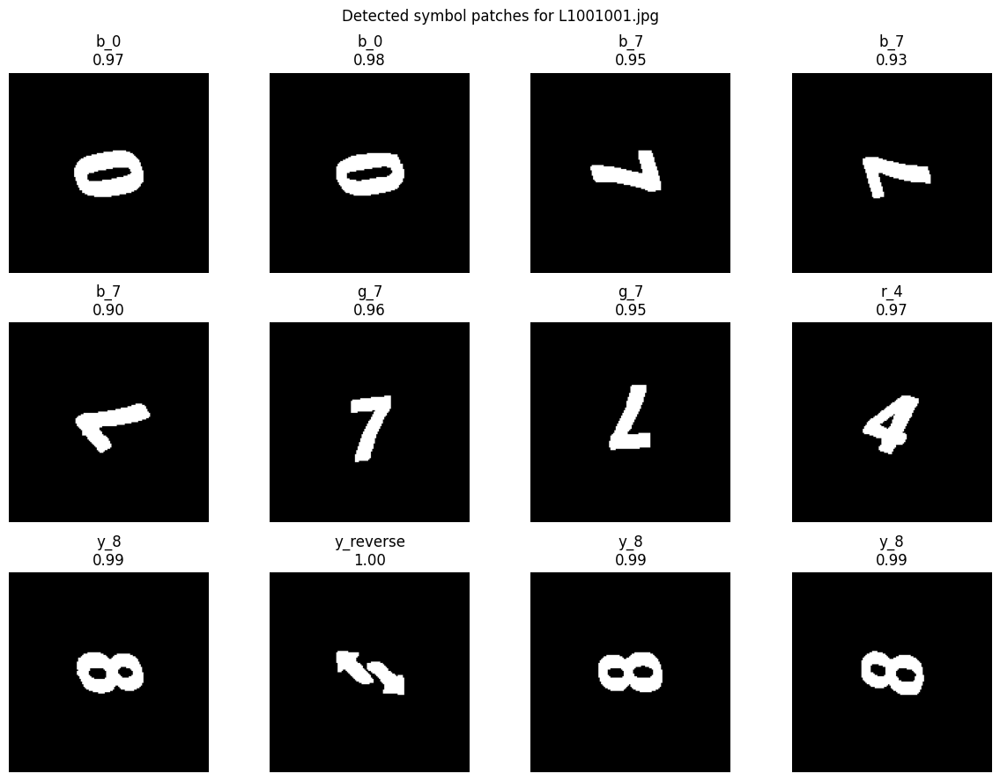

In [26]:
classifier = Classifier(MODEL_PATH, device='auto')
example_frame = IMAGE_PATH
print('Example frame:', example_frame.name)
debug_example = show_patch_predictions(example_frame, classifier)
plt.show()


## 5. Attribution of the central card and the player cards

After symbol classification, the pipeline first assigns detections to the center pile or to one of the four players. The cards closest to the image center are treated as center-pile candidates. The most confident center candidate becomes the central card, while the remaining detections are clustered and assigned to the players. The figure below shows **all detected cards** before duplicate deletion.


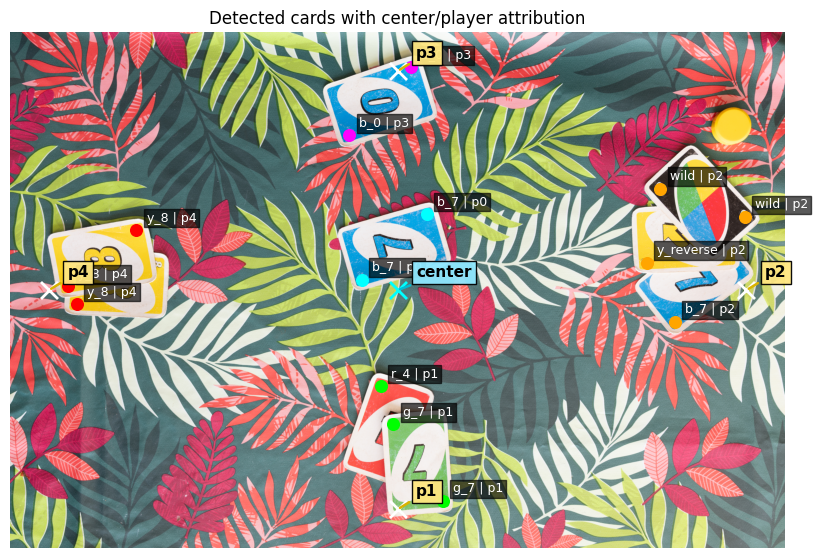

{'image_id': 'L1001001',
 'center_card': 'b_7',
 'active_player': 'p2',
 'player_1_cards': 'r_4;g_7',
 'player_2_cards': 'wild;y_reverse;b_7',
 'player_3_cards': 'b_0',
 'player_4_cards': 'y_8;y_8'}

In [27]:
show_pipeline_assignments(debug_example, show_image=True, remove_duplicates=False, show_anchors=True)
plt.show()
debug_example['row']


## 6. Attribution of the token to a player

Once card detections have been assigned, the token center is detected by the segmentation pipeline. The active player is then obtained by assigning the token to the nearest player anchor position (bottom/right/top/left).


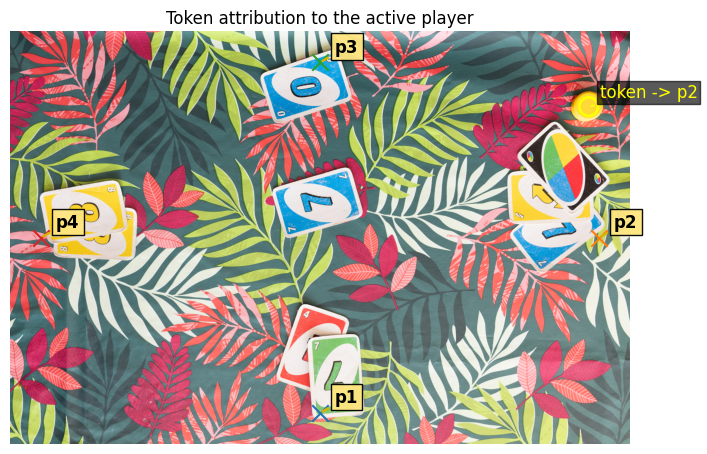

Active player: p2


In [28]:
show_token_assignment(debug_example)
plt.show()
print('Active player:', debug_example['active_player'])

## 7. Logic used to delete duplicated card detections

The duplicate-card deletion is applied after the player cards have been assigned. If two detections of the same card label are separated by the expected duplicate distance, one is removed so that a single physical card is counted only once.

The next cells reuse the same shared demo frame as the rest of the notebook and print the card lists before and after deletion.


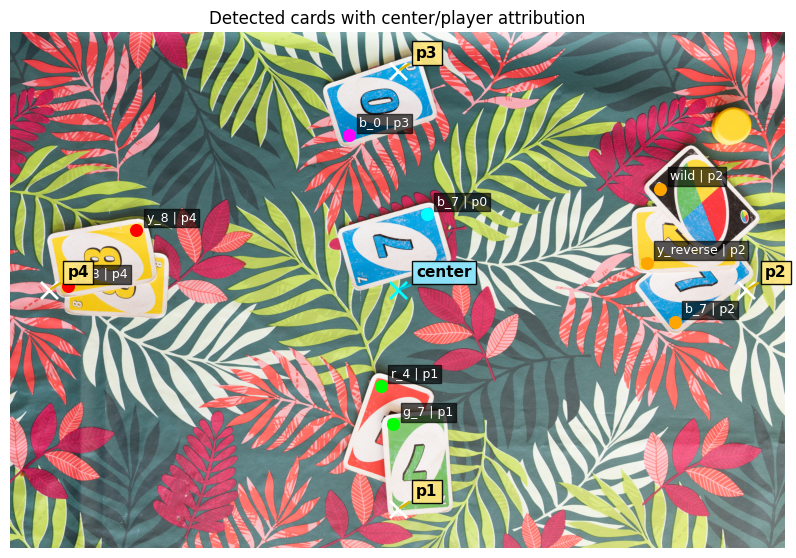

Player 1
  before: ['r_4', 'g_7', 'g_7']
  after:  ['r_4', 'g_7']
Player 2
  before: ['wild', 'wild', 'y_reverse', 'b_7']
  after:  ['wild', 'y_reverse', 'b_7']
Player 3
  before: ['b_0', 'b_0']
  after:  ['b_0']
Player 4
  before: ['y_8', 'y_8', 'y_8']
  after:  ['y_8', 'y_8']


In [29]:
show_pipeline_assignments(debug_example, show_image=True, remove_duplicates=True)
plt.show()
show_duplicate_collapse(debug_example)


## 8. One full pipeline run on a frame

This final example shows the complete output of the pipeline for one frame: detected symbols, player assignment, center card, active player, and the final csv row.

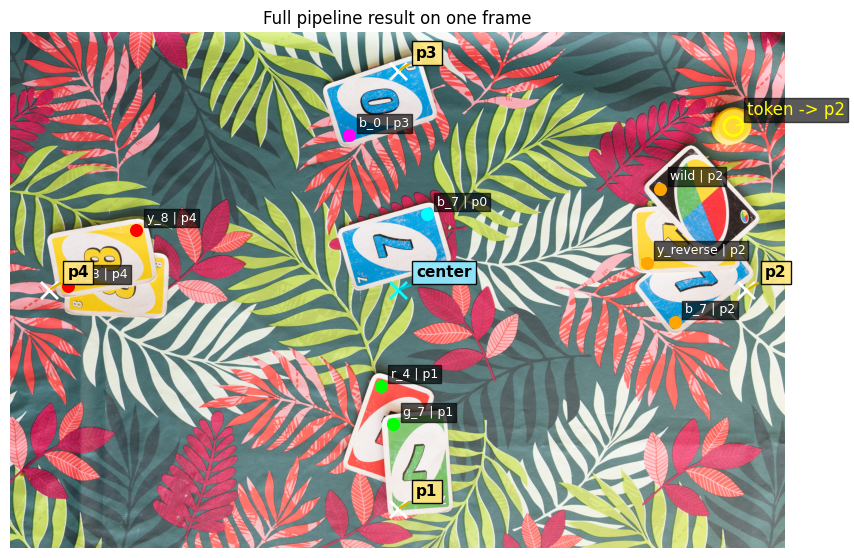

{'image_id': 'L1001001',
 'center_card': 'b_7',
 'active_player': 'p2',
 'player_1_cards': 'r_4;g_7',
 'player_2_cards': 'wild;y_reverse;b_7',
 'player_3_cards': 'b_0',
 'player_4_cards': 'y_8;y_8'}

In [30]:
full_debug = build_pipeline_debug(example_frame, classifier)
show_full_pipeline_frame(full_debug, remove_duplicates=True)
plt.show()
full_debug['row']
